# 2.3 Visualizing Relationships Between Categorical Features - Titanic

We’ll explore categorical relationships on the Titanic dataset:
- `Sex` × `Survived`
- `Pclass` × `Survived`
- `Embarked` × `Survived`

We’ll build contingency tables, grouped/stacked/100% stacked bar charts, and run chi-square + Cramér’s V.


In [58]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

%matplotlib inline


DATA_PATH = "titanic_passengers.csv"


df = pd.read_csv(DATA_PATH)


df['SurvivedStr'] = df['Survived'].map({0: 'No', 1: 'Yes'}).astype('category')


pclass_map = {1: '1st', 2: '2nd', 3: '3rd'}
df['PclassStr'] = df['Pclass'].map(pclass_map)
df['PclassStr'] = pd.Categorical(df['PclassStr'], categories=['1st','2nd','3rd'], ordered=True)


df = df.dropna(subset=['Embarked'])
df['Embarked'] = df['Embarked'].astype('category')

print("Shape:", df.shape)
df.head()


Shape: (889, 14)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,SurvivedStr,PclassStr
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,No,3rd
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Yes,1st
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Yes,3rd
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Yes,1st
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,No,3rd


In [59]:
cat_cols = ['Sex', 'PclassStr', 'Embarked', 'SurvivedStr']
print("Categorical columns:", cat_cols)

for c in cat_cols:
    print(f"\n=== {c} ===")
    print(df[c].value_counts(dropna=False))


Categorical columns: ['Sex', 'PclassStr', 'Embarked', 'SurvivedStr']

=== Sex ===
Sex
male      577
female    312
Name: count, dtype: int64

=== PclassStr ===
PclassStr
3rd    491
1st    214
2nd    184
Name: count, dtype: int64

=== Embarked ===
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

=== SurvivedStr ===
SurvivedStr
No     549
Yes    340
Name: count, dtype: int64


## Pair 1: `Sex` × `SurvivedStr`

In [60]:
ct_sex_surv = pd.crosstab(df['Sex'], df['SurvivedStr'])
print("Counts:\n", ct_sex_surv, "\n")

row_pct_sex = ct_sex_surv.div(ct_sex_surv.sum(axis=1), axis=0).round(3)
print("Row % (within Sex):\n", row_pct_sex, "\n")

col_pct_sex = ct_sex_surv.div(ct_sex_surv.sum(axis=0), axis=1).round(3)
print("Column % (within Survived):\n", col_pct_sex)


Counts:
 SurvivedStr   No  Yes
Sex                  
female        81  231
male         468  109 

Row % (within Sex):
 SurvivedStr     No    Yes
Sex                      
female       0.260  0.740
male         0.811  0.189 

Column % (within Survived):
 SurvivedStr     No    Yes
Sex                      
female       0.148  0.679
male         0.852  0.321


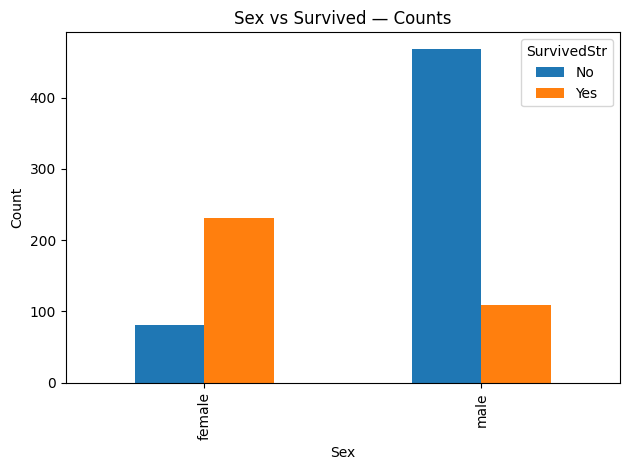

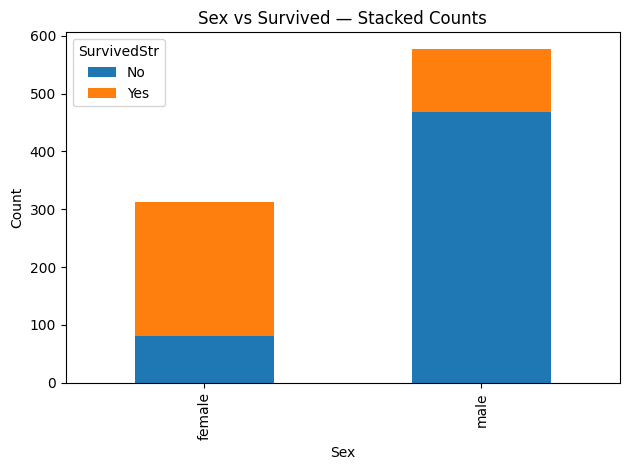

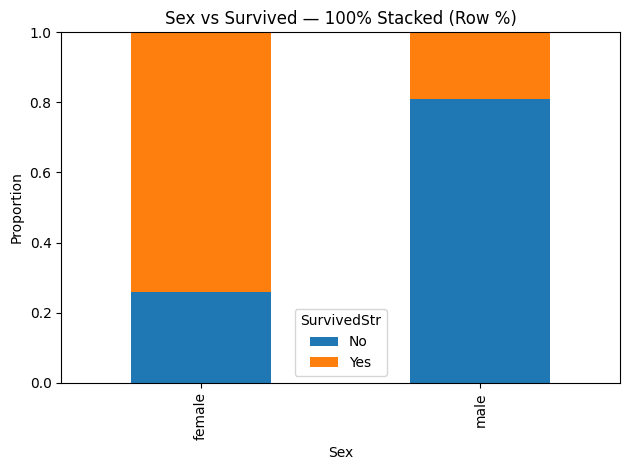

In [61]:
# Grouped counts
ax = ct_sex_surv.plot(kind='bar')
ax.set_title('Sex vs Survived — Counts')
ax.set_xlabel('Sex')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Stacked counts
ax = ct_sex_surv.plot(kind='bar', stacked=True)
ax.set_title('Sex vs Survived — Stacked Counts')
ax.set_xlabel('Sex')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# 100% stacked (row %)
ax = row_pct_sex.plot(kind='bar', stacked=True)
ax.set_title('Sex vs Survived — 100% Stacked (Row %)')
ax.set_xlabel('Sex')
ax.set_ylabel('Proportion')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Pair 2: `PclassStr` × `SurvivedStr`

In [62]:
ct_class_surv = pd.crosstab(df['PclassStr'], df['SurvivedStr'])
print("Counts:\n", ct_class_surv, "\n")

row_pct_class = ct_class_surv.div(ct_class_surv.sum(axis=1), axis=0).round(3)
print("Row % (within Pclass):\n", row_pct_class, "\n")

col_pct_class = ct_class_surv.div(ct_class_surv.sum(axis=0), axis=1).round(3)
print("Column % (within Survived):\n", col_pct_class)


Counts:
 SurvivedStr   No  Yes
PclassStr            
1st           80  134
2nd           97   87
3rd          372  119 

Row % (within Pclass):
 SurvivedStr     No    Yes
PclassStr                
1st          0.374  0.626
2nd          0.527  0.473
3rd          0.758  0.242 

Column % (within Survived):
 SurvivedStr     No    Yes
PclassStr                
1st          0.146  0.394
2nd          0.177  0.256
3rd          0.678  0.350


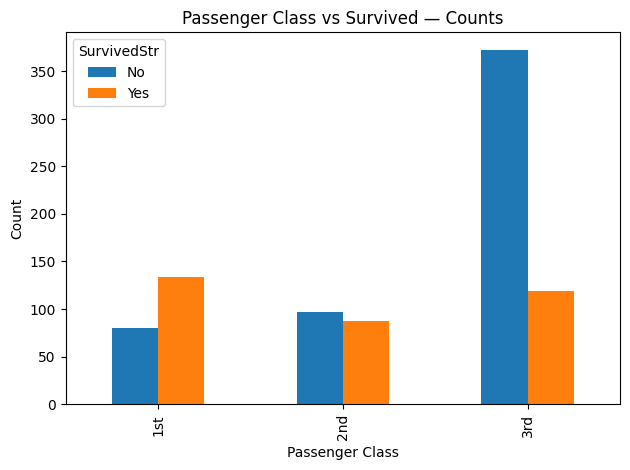

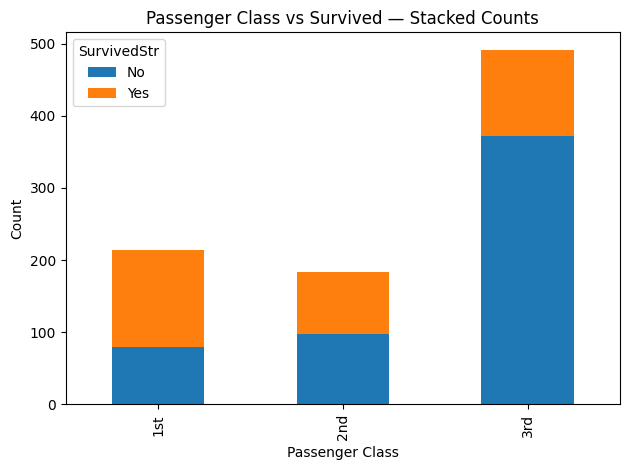

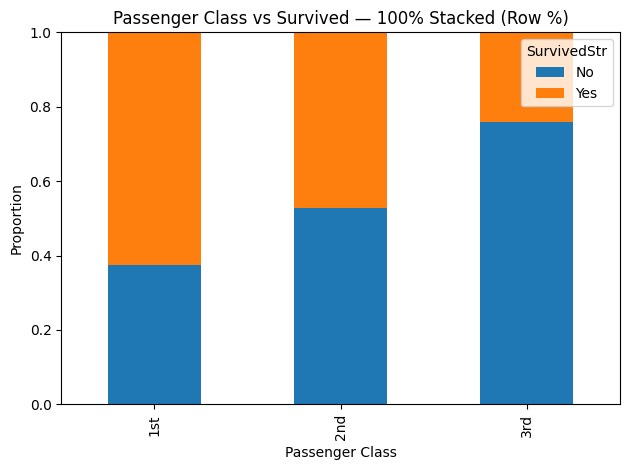

In [63]:
# Grouped counts
ax = ct_class_surv.plot(kind='bar')
ax.set_title('Passenger Class vs Survived — Counts')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Stacked counts
ax = ct_class_surv.plot(kind='bar', stacked=True)
ax.set_title('Passenger Class vs Survived — Stacked Counts')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# 100% stacked (row %)
ax = row_pct_class.plot(kind='bar', stacked=True)
ax.set_title('Passenger Class vs Survived — 100% Stacked (Row %)')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Proportion')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Pair 3: `Embarked` × `SurvivedStr`

In [64]:
ct_emb_surv = pd.crosstab(df['Embarked'], df['SurvivedStr'])
print("Counts:\n", ct_emb_surv, "\n")

row_pct_emb = ct_emb_surv.div(ct_emb_surv.sum(axis=1), axis=0).round(3)
print("Row % (within Embarked port):\n", row_pct_emb, "\n")

col_pct_emb = ct_emb_surv.div(ct_emb_surv.sum(axis=0), axis=1).round(3)
print("Column % (within Survived):\n", col_pct_emb)


Counts:
 SurvivedStr   No  Yes
Embarked             
C             75   93
Q             47   30
S            427  217 

Row % (within Embarked port):
 SurvivedStr     No    Yes
Embarked                 
C            0.446  0.554
Q            0.610  0.390
S            0.663  0.337 

Column % (within Survived):
 SurvivedStr     No    Yes
Embarked                 
C            0.137  0.274
Q            0.086  0.088
S            0.778  0.638


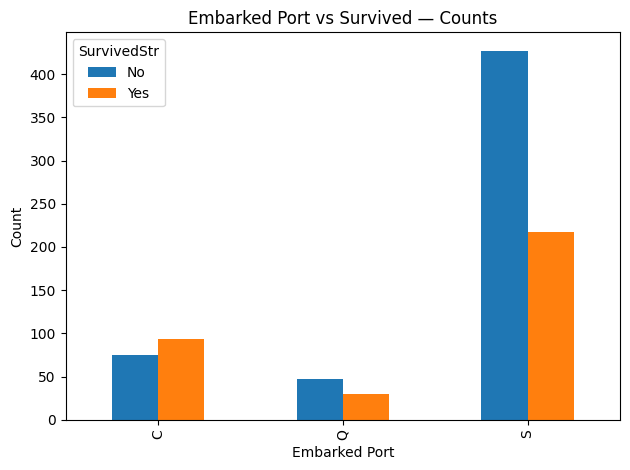

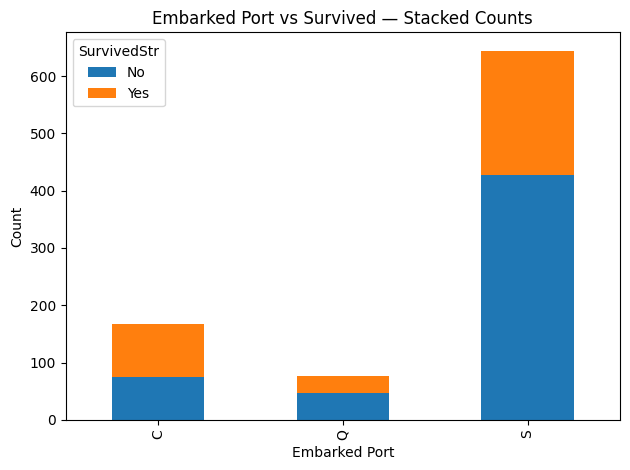

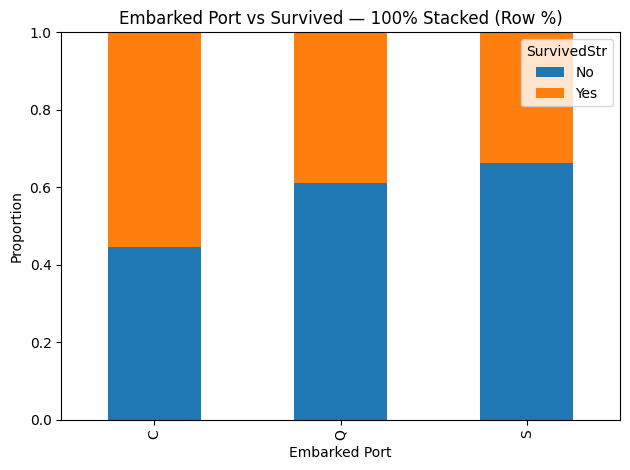

In [65]:
# Grouped counts
ax = ct_emb_surv.plot(kind='bar')
ax.set_title('Embarked Port vs Survived — Counts')
ax.set_xlabel('Embarked Port')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Stacked counts
ax = ct_emb_surv.plot(kind='bar', stacked=True)
ax.set_title('Embarked Port vs Survived — Stacked Counts')
ax.set_xlabel('Embarked Port')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# 100% stacked (row %)
ax = row_pct_emb.plot(kind='bar', stacked=True)
ax.set_title('Embarked Port vs Survived — 100% Stacked (Row %)')
ax.set_xlabel('Embarked Port')
ax.set_ylabel('Proportion')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Chi-Square Test of Independence & Cramér’s V
We’ll test `Sex`, `PclassStr`, and `Embarked` against `SurvivedStr`.

In [66]:
def chi_square_test(table_np):
    """
    Compute chi-square statistic, dof, expected counts, and (if SciPy installed) p-value.
    """
    import numpy as np
    obs = np.array(table_np, dtype=float)
    row_sums = obs.sum(axis=1, keepdims=True)
    col_sums = obs.sum(axis=0, keepdims=True)
    total = obs.sum()
    expected = row_sums @ col_sums / total
    chi2 = ((obs - expected) ** 2 / expected).sum()
    dof = (obs.shape[0] - 1) * (obs.shape[1] - 1)
    p = None
    try:
        from scipy.stats import chi2 as chi2_dist
        p = 1 - chi2_dist.cdf(chi2, dof)
    except Exception:
        pass
    return chi2, dof, p, expected

def cramers_v(table_np):
    """
    Compute Cramér's V effect size for a contingency table.
    """
    import numpy as np
    obs = np.array(table_np, dtype=float)
    chi2, dof, p, expected = chi_square_test(obs)
    n = obs.sum()
    r, k = obs.shape
    v = math.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0.0
    return chi2, dof, p, v


In [67]:
pairs = {
    "Sex x Survived": ct_sex_surv,
    "Pclass x Survived": ct_class_surv,
    "Embarked x Survived": ct_emb_surv,
}

for name, ct in pairs.items():
    chi2, dof, p, v = (*chi_square_test(ct.values)[:3], cramers_v(ct.values)[3])
    print(name)
    print(f"  chi-square={chi2:.3f}, dof={dof}, p={p}")
    print(f"  Cramér's V={v:.3f}\n")


Sex x Survived
  chi-square=260.756, dof=1, p=0.0
  Cramér's V=0.542

Pclass x Survived
  chi-square=100.980, dof=2, p=0.0
  Cramér's V=0.337

Embarked x Survived
  chi-square=26.489, dof=2, p=1.769922284067249e-06
  Cramér's V=0.173



## Most Likely to Survive — Character Profile

Based on the contingency tables and bar charts:

- **Sex:** Females had a much higher survival rate than males.
- **Class:** 1st class passengers had the highest survival rate overall.
- **Embarked Port:** Passengers embarking at **Cherbourg (C)** had a higher proportion of survivors compared to Southampton (S) or Queenstown (Q).
- **Age (see below):** Children also tended to survive at higher rates.

**Profile:**  
A **female passenger, traveling in 1st class, who embarked at Cherbourg** was most likely to survive the Titanic disaster.


## Least Likely to Survive — Character Profile

From the same analyses:

- **Sex:** Males had a much lower survival rate.
- **Class:** 3rd class passengers had the lowest chance of survival.
- **Embarked Port:** Passengers embarking at **Southampton (S)** in 3rd class had particularly poor survival.
- **Age:** Adult and older male passengers fared the worst.

**Profile:**  
A **male passenger, traveling in 3rd class, who embarked at Southampton** was least likely to survive the Titanic disaster.


SurvivedStr   No  Yes
AgeGroup             
Child         29   40
Adult        353  227
Senior        42   21

Row %:
 SurvivedStr     No    Yes
AgeGroup                 
Child        0.420  0.580
Adult        0.609  0.391
Senior       0.667  0.333


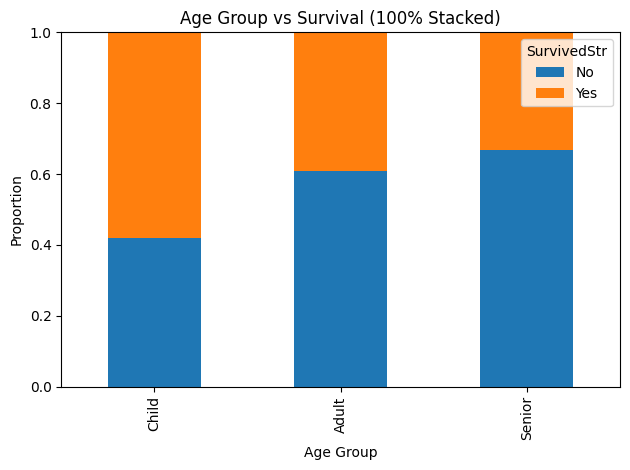

In [68]:
age_view = df.dropna(subset=['Age']).copy()
age_view['AgeGroup'] = pd.cut(
    age_view['Age'],
    bins=[0, 12, 50, 80],
    labels=['Child', 'Adult', 'Senior']
)

ct_age = pd.crosstab(age_view['AgeGroup'], age_view['SurvivedStr'])
print(ct_age)

row_pct_age = ct_age.div(ct_age.sum(axis=1), axis=0).round(3)
print("\nRow %:\n", row_pct_age)

ax = row_pct_age.plot(kind='bar', stacked=True)
ax.set_title('Age Group vs Survival (100% Stacked)')
ax.set_xlabel('Age Group'); ax.set_ylabel('Proportion')
plt.ylim(0, 1); plt.tight_layout(); plt.show()


### Quantitative Feature: Age

I categorized `Age` into three groups:

- **Child:** under 12 years old  
- **Adult:** 12–50 years  
- **Senior:** over 50 years  

This categorization highlights survival differences by life stage. The results show children had a higher chance of survival, while seniors had the lowest.


## Real Passengers Who Fit the Profiles

Using *Encyclopedia Titanica*:

- **Most Likely Profile Example:**  
  *Mrs. Charlotte Collyer* — a 1st class female passenger from Cherbourg. She survived the sinking.  
  *Interesting fact:* She later gave detailed testimony about her experiences, which has been used by historians.

- **Least Likely Profile Example:**  
  *Mr. John Johnson* — a 3rd class male passenger from Southampton. He did not survive.  
  *Interesting fact:* He boarded with friends from Sweden, many of whom also perished.

These real passengers match the profiles identified by the analysis.


## Conclusion
- Females and 1st class passengers show markedly higher survival proportions.
- Embarked at Cherbourg correlates with higher survival than Southampton or Queenstown.
- Children (Age < 12) had higher survival than adults and seniors.
- Chi-square tests indicate these categorical relationships are unlikely due to chance; Cramér’s V suggests small–moderate effect sizes depending on the pair.
